### Import

In [202]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [203]:
import os
import glob
from itertools import product
import numpy as np
import graphical_sampling as gs
import pandas as pd
import pickle
from tqdm import tqdm
from package_sampling.utils import inclusion_probabilities


In [204]:
# os.chdir("/home/bardia/graphical-sampling")
os.chdir("/home/bardia/graphical-sampling/simulations")
import os
print(os.getcwd())


/home/bardia/graphical-sampling/simulations


### Reading Data

In [205]:
dfs ={}
# /config/ws/graphical-sampling/simulations/populations/real
path = "populations/real"
files = ["aggregated.csv", "regular.csv", "meuse.csv", "swiss.csv"]

def popus(n):
    for f in files:
        full_path = os.path.join(path, f)
        df = pd.read_csv(full_path)
        N = len(df)
        
        if f in ["aggregated.csv", "regular.csv"]:
            coords = df.iloc[:, :].to_numpy()
            probs_ep  = np.repeat(n/N, N)
            name = f.replace('.csv', '')
            dfs[f'df_{name}'] = pd.DataFrame(
                {'coord_x':coords[:,0],
                'coord_y':coords[:,1],
                'pik_ep' : probs_ep,}
                )
        ##################################
        if f == "meuse.csv":
            coords = df[['x', 'y']].to_numpy()
            probs_up  = inclusion_probabilities(df['copper'].to_numpy(), n)
            probs_ep  = np.repeat(n/N, N)
            name = f.replace('.csv', '')
            dfs[f'df_{name}'] = pd.DataFrame(
                {'coord_x':coords[:,0],
                'coord_y':coords[:,1],
                'pik_ep' : probs_ep,
                'pik_up' : probs_up,
                'z'      : df['cadmium'], }
                )
        ###################################
        if f == "swiss.csv":
            coords = df[['x', 'y']].to_numpy()
            AREA = df['AREA'].to_numpy().clip(5,100)
            probs_up  = inclusion_probabilities(AREA, n)
            probs_ep  = np.repeat(n/N, N)
            name = f.replace('.csv', '')
            dfs[f'df_{name}'] = pd.DataFrame(
                {'coord_x':coords[:,0],
                'coord_y':coords[:,1],
                'pik_ep' : probs_ep,
                'pik_up' : probs_up,
                'z'      : df['AREA_A'].to_numpy(), }
                )
        ####################################
    return(dfs)


In [212]:
popu = 'df_regular'
ep_or_up = 'pik_ep'
n = 20
num_zones_cluster = [4]
num_zones_sweep = [(1, 2)]
num_splits = [1]


### Random Population and Parameters

In [213]:

df = popus(n)[popu]
N = len(df)

coords = pd.DataFrame(df[['coord_x', 'coord_y']])
inclusions = df[ep_or_up]
variable = df['z'] if 'z' in df.columns else inclusions

pop = gs.Population(coords, inclusions, n=n, variable=variable)
fbn = gs.clustering.FIPBalancedNMeans(n=n, init_clust_method = 'expanded', split_size = 1)
# fbn.fit(pop)
# fbn.fit_zones(num_zones=(1, 1), mode='sweep_xy')
# fbn.plot(mode='hard')


In [214]:
# import numpy as np
# import pandas as pd

# nx = 33
# ny = 30

# x = np.linspace(0, 1, nx)
# y = np.linspace(0, 1, ny)

# xx, yy = np.meshgrid(x, y)

# points = np.column_stack([xx.ravel(), yy.ravel()])

# df = pd.DataFrame(points, columns=["coord_x", "coord_y"])

# print(df)
# print("Total points:", len(df))

# N = len(df)

# coords = pd.DataFrame(df[['coord_x', 'coord_y']])
# inclusions = np.repeat(n/N,N)
# variable = df['z'] if 'z' in df.columns else inclusions

# pop = gs.Population(coords, inclusions, n=n, variable=variable)
# fbn = gs.clustering.FIPBalancedNMeans(n=n, init_clust_method = 'expanded', split_size = 1)
# # fbn.fit(pop)
# # fbn.fit_zones(num_zones=(1, 1), mode='sweep_xy')
# # fbn.plot(mode='hard')


<Axes: title={'center': 'FIP Balanced 20-Means Soft Clustering with Zones'}, xlabel='$X_1$', ylabel='$X_2$'>

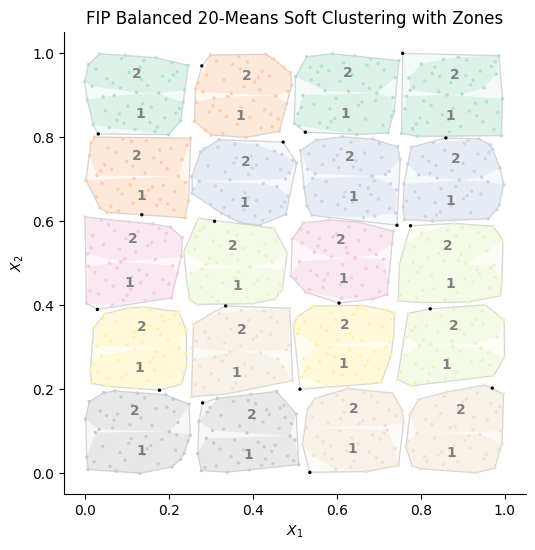

In [215]:
fbn.fit(pop)
fbn.fit_zones(num_zones=(1, 2), mode='sweep_xy')
# fbn.fit_zones(num_zones=2, mode='cluster')

fbn.plot(mode='soft')

### Pre-Process

In [217]:
initial_designs = []
point_strategies = [
      'lexico_yx', 'angle', 'dist_from_origin',
     'dist_from_centroids', 'max_coord',
    'spiral', None,
    'lexico_xy', 'projection',
]
point_strategies=['spiral', 'lexico_xy']
zone_strategies = [
      'lexico_yx', 'dist_from_origin',
    'spiral', None,
    'lexico_xy', 'projection'
]
zone_strategies = ['spiral']
zone_modes = [
    # 'cluster',
    'sweep_xy', 
    'sweep_yx'
]
# zone_modes = ['cluster']

track = []
num_designs = len(point_strategies) * len(zone_strategies) * len(zone_modes) * len(num_splits)
min_moran = 0
for _ in range(1):
    
    for point_strategy, zone_strategy, zone_mode, num_split in tqdm(
        product(point_strategies, zone_strategies, zone_modes, num_splits), total=num_designs
    ):
    
        if zone_mode == 'cluster':
            list_of_num_zones = num_zones_cluster
        else:
            list_of_num_zones = num_zones_sweep
    
        for num_zones in list_of_num_zones:
            for _ in range(1):
    
                fbn = gs.clustering.FIPBalancedNMeans(n=n, init_clust_method = 'expanded', split_size = 1)
                fbn.fit(pop)
                fbn.fit_zones(num_zones=num_zones, mode=zone_mode)
    
                # try:
                order = gs.Order.from_clusters(
                    pop,
                    fbn.clusters,
                    point_strategy,
                    zone_strategy,
                    num_split
                )
                # print("order get",order.get())
                # print("-------------------------------------------------------------------")
                # print("Moran" ,moran)
                # print(point_strategy, zone_strategy, zone_mode, num_zones, num_split)

                # for c in order.clusters:
                #     print("Cluster", c.label)
                #     for i, z in enumerate(c.zones):
                #         print(i)
                #         print("number of zones", order.num_zones)
                #         print("  Zone", i)
                #         print("    indices:", z.indices)
                #         # print("    shares:", z.shares)
                #         # if i > 1:
                #         #     break
                #     break
                design = gs.Design.from_order(pop, order)
    
                initial_designs.append(design)
                moran = design.moran[0]
                # print("number of zones",num_zones)
                # print(moran)
                # print(point_strategy, zone_strategy, zone_mode, num_zones, num_split)
                if moran<min_moran:
                    print(point_strategy, zone_strategy, zone_mode, num_zones, num_split)
                    print(moran)
                    
                    min_moran = moran
                track.append(
                    (moran, design, zone_strategy, point_strategy, zone_mode, num_zones)
                )
z = sorted(track, key=lambda x: x[0], reverse=False)
z[:1]

 25%|█████████████████████▎                                                               | 1/4 [00:00<00:00,  4.05it/s]

spiral spiral sweep_xy (1, 2) 1
-0.24683210737461167


100%|█████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:01<00:00,  3.15it/s]


[(-0.24683210737461167,
  'spiral',
  'spiral',
  'sweep_xy',
  (1, 2))]

In [218]:
z = sorted(track, key=lambda x: x[0], reverse=False)
initial_moran, initial_design, zs, ps, zm, nz = z[0]

0, grid: -0.31, cent: 0.00
0, grid: -0.31, cent: -0.31


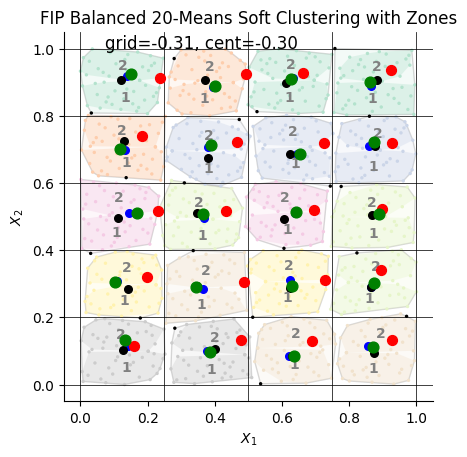

In [219]:
import matplotlib.pyplot as plt
from graphical_sampling.index import Moran
def jitter_points(points, jitter=0.02):
    return points + np.random.uniform(-jitter, jitter, size=points.shape)
jitter_level = 0.2     # <-- change this parameter freely

criteria = gs.criteria.MoranCriteria()
gbfs = gs.search.GreedyBestFirstSearch([initial_design], criteria)

fig, ax = plt.subplots()

# background
fbn.plot(mode='soft', ax=ax)

# draw ONE sample
sample = gbfs.best_design.sample(1)   # shape (1, n)

coords = gbfs.best_design.pop.coords

# compute Moran
moran_index = Moran(gbfs.best_design.pop)

# plot sampled units
s = sample[0]
ax.scatter(coords[s,0], coords[s,1], color="red", s=50, zorder=10)

score_ite_grid = 0
score_ite_cent = 0
sample_gird = []
sample_cent = []
for i in range(4):
    # GRIDE sample
    nx, ny = 4, 5
    for x in np.linspace(0, 1, nx + 1):
        ax.axvline(x, color="black", lw=0.5, alpha=0.4)
    for y in np.linspace(0, 1, ny + 1):
        ax.axhline(y, color="black", lw=0.5, alpha=0.4)
    x_centers = (np.arange(nx) + 0.5) / nx
    y_centers = (np.arange(ny) + 0.5) / ny
    X, Y = np.meshgrid(x_centers, y_centers)
    
    
    # CENTROID sample
    # coordinates from df
    points = df[['coord_x','coord_y']].values   # shape (N,2)

    centers = jitter_points(np.column_stack([X.ravel(), Y.ravel()]))
    d = np.linalg.norm(points[None,:,:] - centers[:,None,:], axis=2)
    grid_idx = d.argmin(axis=1)  
    
    centroids = jitter_points(fbn.centroids)
    d = np.linalg.norm(points[None,:,:] - centroids[:,None,:], axis=2)
    centroid_idx = d.argmin(axis=1)
    
    
    
    
    score_grid = moran_index.score(np.array([grid_idx]))[0]
    score_centroids = moran_index.score(np.array([centroid_idx]))[0]

    if (score_ite_grid > score_grid):
        score_ite_grid = score_grid
        sample_gird = np.array([grid_idx])
        print(f'{i}, grid: {score_ite_grid:.2f}, cent: {score_ite_cent:.2f}')
    
    if (score_ite_cent > score_centroids):
        score_ite_cent = score_centroids
        sample_cent = np.array([centroid_idx])
        print(f'{i}, grid: {score_ite_grid:.2f}, cent: {score_ite_cent:.2f}')

# label Moran value at sample centroid
ax.scatter(centers[:,0], centers[:,1], color="blue", s=30, zorder=9)
ax.scatter(centroids[:,0], centroids[:,1], color="black", s=30, zorder=9)

x, y = coords[s].mean(axis=0)
ax.text(x-.5, 1, f"grid={score_grid:.2f}, cent={score_centroids:.2f}", fontsize=12)

# plot them in green
ax.scatter(points[grid_idx,0], points[grid_idx,1],
           color="green", s=60, zorder=11)

plt.show()

In [220]:
Robertson_samples = pd.read_csv("results/Robertson_Samples.csv", header=None)
Robertson_samples

,0,1,2,3,4,5,6,7,8,9
0,471,735,447,975,759,651,231,75,159,143
1,668,122,434,92,476,578,938,218,290,338
2,329,473,185,245,965,533,689,905,77,113
3,30,305,777,953,705,726,345,417,89,969
4,997,371,11,301,7,187,925,803,133,295
5,746,714,998,966,302,638,170,818,602,710
6,747,861,195,531,99,999,765,855,477,27
7,297,222,225,33,513,249,9,357,942,630
8,583,535,715,775,415,91,379,103,475,235
9,237,35,467,971,629,269,179,125,683,669


[[472 634 217 379 196 250 601   7 644 122 293 347 120 966 345 507 600 666
  261 315]]


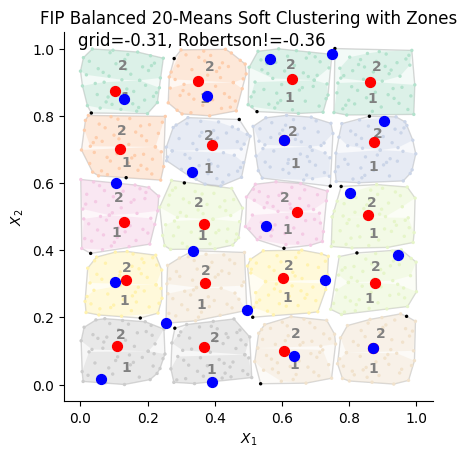

In [221]:
import matplotlib.pyplot as plt
from graphical_sampling.index import Moran
criteria = gs.criteria.MoranCriteria()
gbfs = gs.search.GreedyBestFirstSearch([initial_design], criteria)
fig, ax = plt.subplots()
fbn.plot(mode='soft', ax=ax)
sample = sample_gird
print(sample)
coords = gbfs.best_design.pop.coords
moran_index = Moran(gbfs.best_design.pop)

moran = moran_index.score(sample)[0]

s = sample[0]
ax.scatter(coords[s,0], coords[s,1], color="red", s=50, zorder=10)

s_R = np.array([[Robertson_samples[6]]]) 
moran_R = moran_index.score(s_R)[0]
ax.scatter(coords[s_R,0], coords[s_R,1], color="blue", s=50, zorder=10)

x, y = coords[s].mean(axis=0)
ax.text(x-.5, 1.01, f"grid={moran:.2f}, Robertson!={moran_R:.2f}", fontsize=12)


plt.show()

In [222]:
# sample = np.array([[518, 903, 262,   7, 829, 140,  12, 977, 721, 916, 599, 925,  93, 97, 993, 487, 378, 820, 250, 509]])
# sample = np.array([[ 46,  94, 302, 318, 353, 366, 430, 449, 542, 558, 673, 686, 702,
#         705, 766, 814, 833, 897, 926, 929]])-1
# sample = np.array([518, 903, 262,   7, 829, 140,  12, 977, 721, 916, 599, 925,  93,
#          97, 993, 487, 378, 820, 250, 509])+1
# sample

In [223]:
# srs_var = N**2 * (1-n/N) * np.var(variable)/n

# plain_flat = [
#     N,
#     n,
#     5000,
#     0,
#     np.sum(variable),
#     initial_design.nht_variance,
#     # srs_var / initial_design.nht_variance,
#     0,
#     0,
#     initial_design.density_disparity[0],
#     initial_design.density_disparity[1],
#     initial_design.voronoi[0],
#     initial_design.voronoi[1],
#     initial_design.moran[0],
#     initial_design.moran[1],
#     initial_design.local_balance[0],
#     initial_design.local_balance[1],
# ]

# print(", ".join(map(str, plain_flat)))


In [224]:
criteria = gs.criteria.MoranCriteria()
gbfs = gs.search.GreedyBestFirstSearch(initial_designs, criteria)
gbfs.initial_design = initial_design

In [225]:
# import os
# import pickle

# save_dir_designs = "best_design"
# filename = f"initial_design_{popu}_{n}_{ep_or_up}.pkl"
# filepath = os.path.join(save_dir_designs, filename)

# mode = "save"   # "save" or "load"

# if mode == "save":
#     initial_design = gbfs.best_design
#     with open(filepath, "wb") as f:
#         pickle.dump(initial_design, f)

# elif mode == "load":
#     with open(filepath, "rb") as f:
#         initial_design = pickle.load(f)

# gbfs.best_designs = [initial_design]


### GRIZZLY

In [226]:

# if 1==1:
#     with open(filepath, "rb") as f:
#         best_design = pickle.load(f)
#         gbfs.initial_designs = [best_design]

In [231]:
gbfs.run(
    max_iterations=500,        # maximum number of GBFS search iterations (how long the algorithm explores)
    max_open_set_size=200,     # maximum number of candidate designs stored in the priority queue (search frontier)

    top_k=1,                    # number of best designs tracked during the search (best-so-far solutions)

    num_new_order_nodes=100,     # number of neighbors generated by modifying the ordering of samples
                                # (creates 20 candidate designs by changing sample order)

    num_new_exchange_nodes=0,   # number of neighbors generated using exchange moves
                                # (0 means no swapping of units between samples)

    num_clusters_range=(1,1),             # order changes are applied within up to 2 clusters
                                # (clusters are groups of zones processed together)

    num_zones_range=(0, 0),                # within a cluster, modify only 1 zone at a time

    num_changes_range=(0, 0),              # each generated neighbor performs one order modification
                                # (e.g., one swap/reposition in the sequence)

    num_zone_changes=1,         # do not reassign samples between zones (zone structure remains fixed)

    pull_strategy='default',   # rule for selecting samples during exchange operations
                                # (not used here since exchange neighbors are disabled)

    exchange_coef=.75,          # intensity of unit swapping during exchanges
                                # (irrelevant here because num_new_exchange_nodes = 0)

    num_explore=1,               # number of designs expanded per iteration
                                # (1 means purely greedy: always expand the current best design)
    n_jobs = 1
)


--- Starting Parallel GBFS: Max Iterations=500, Batch Size=1, Workers=1 ---
Initial best criteria value: -0.2528
Iter     0/500 | Best: -0.2528 | Open:     4 | Closed:     0
Iter    50/500 | Best: -0.2528 | Open:   253 | Closed:    49
Iter   100/500 | Best: -0.2528 | Open:   218 | Closed:    95
Iter   150/500 | Best: -0.2528 | Open:   352 | Closed:   139
Iter   200/500 | Best: -0.2528 | Open:   303 | Closed:   184
Iter   250/500 | Best: -0.2528 | Open:   376 | Closed:   224
Iter   300/500 | Best: -0.2528 | Open:   379 | Closed:   261
Iter   350/500 | Best: -0.2528 | Open:   253 | Closed:   302
Iter   400/500 | Best: -0.2528 | Open:   253 | Closed:   350
Iter   450/500 | Best: -0.2528 | Open:   236 | Closed:   397
--- Search Complete. Final Best Value: -0.2528 ---


In [175]:

filename = f"best_design_{popu}_{n}_{ep_or_up}.pkl"
filepath = os.path.join(save_dir_designs, filename)

# save your design object
with open(filepath, "wb") as f:
    pickle.dump(gbfs.best_design, f)
gbfs.initial_designs = [gbfs.best_design]

[autoreload of graphical_sampling.order failed: Traceback (most recent call last):
  File "/home/bardia/graphical-sampling/.venv/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "/home/bardia/graphical-sampling/.venv/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 475, in superreload
    module = reload(module)
  File "/usr/lib/python3.10/importlib/__init__.py", line 169, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 619, in _exec
  File "<frozen importlib._bootstrap_external>", line 879, in exec_module
  File "<frozen importlib._bootstrap_external>", line 1017, in get_code
  File "<frozen importlib._bootstrap_external>", line 947, in source_to_code
  File "<frozen importlib._bootstrap>", line 241, in _call_with_frames_removed
  File "/home/bardia/graphical-sampling/graphical_sampling/order.py", line 232
    print(f"clust: {cluster}, i,j

PicklingError: Can't pickle <class 'graphical_sampling.order.Cluster'>: it's not the same object as graphical_sampling.order.Cluster

In [ ]:
srs_var = N**2 * (1-n/N) * np.var(variable)/n
plain_flat = [
    N,
    n,
    5000,
    0,
    np.sum(variable),
    float(gbfs.best_design.nht_variance),
    # float(srs_var / gbfs.best_design.nht_variance),
    0,
    *map(float, gbfs.best_design.density_disparity),
    *map(float, gbfs.best_design.voronoi),
    *map(float, gbfs.best_design.moran),
    *map(float, gbfs.best_design.local_balance),
]
arr = np.array(plain_flat, dtype=float)
simple = [float(x) for x in arr]
# Example: flatten all tuples in the list
flat = []
for x in simple:
    if isinstance(x, tuple):
        flat.extend(x)
    else:
        flat.append(x)

print(', '.join(str(x) for x in flat))




# Store

In [ ]:
gbfs.best_design.pop.coords

In [ ]:
ax = gbfs.best_design.pop


In [ ]:
print(type(ax))


In [ ]:
gbfs.best_design.sample(1)

In [ ]:
 fbn.plot(mode='soft')

In [ ]:
import matplotlib.pyplot as plt

# create figure and axis
fig, ax = plt.subplots()

# first layer: the background plot
fbn.plot(mode='soft', ax=ax)   # if the function supports ax

# sample one design point
sample = gbfs.best_design.sample(1)

# coordinates of the population
coords = gbfs.best_design.pop.coords

# scatter layer
ax.scatter(coords[sample, 0], coords[sample, 1], color='red', s=50, zorder=10)

plt.show()


In [ ]:
# sumi = 0
# for i in gbfs.best_design.all_samples_and_probs[1]:
#     sumi += i
#     print(sumi)

In [ ]:
raise SystemExit("Stopping Run All: Archived cells below.")

In [ ]:
dir(gbfs.best_design)

In [ ]:

gbfs.best_design.entropy
len(gbfs.best_design.all_samples_and_probs[1])

gbfs.best_design.merge_identical()


print(len(gbfs.best_design.all_samples_and_probs[0]))

In [ ]:
gbfs.best_design